# Hotel Booking Cancellation Prediction using Deep Learning

## Business Problem
Hotel booking cancellations create major financial and operational challenges for hotels. 
Late cancellations can lead to revenue loss, inefficient room allocation, and inaccurate demand forecasting.

This project uses Deep Learning techniques to predict whether a hotel booking will be canceled based on customer and reservation information.

---

## Project Goals
- Predict booking cancellations
- Reduce financial losses
- Improve hotel resource planning
- Explore neural network performance on tabular business data

---

## Technologies Used
- Python
- Pandas
- Scikit-learn
- TensorFlow / Keras
- Matplotlib

---

## Dataset
Hotel Booking Demand Dataset

# Importing Libraries

In this section, we import all required libraries for:
- data processing
- visualization
- preprocessing
- machine learning pipelines
- deep learning

In [1]:
# Setup plotting
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

plt.style.use('seaborn-v0_8-whitegrid')

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc(
    'axes',
    labelweight='bold',
    labelsize='large',
    titleweight='bold',
    titlesize=18,
    titlepad=10
)

plt.rc('animation', html='html5')

# Loading the Dataset

We load the hotel booking dataset and separate:
- input features (X)
- target variable (y)

Target:
- `is_canceled`
    - 1 → booking canceled
    - 0 → booking not canceled

In [2]:
hotel = pd.read_csv('../data/hotel.csv')

X = hotel.copy()
y = X.pop('is_canceled')

#The dataset contains month names as text values.
X['arrival_date_month'] = \
    X['arrival_date_month'].map(
        {'January':1, 'February': 2, 'March':3,
         'April':4, 'May':5, 'June':6, 'July':7,
         'August':8, 'September':9, 'October':10,
         'November':11, 'December':12}
    )

# Selecting Numerical and Categorical Features

The dataset contains:
- numerical features
- categorical features

We separate them because each type requires different preprocessing techniques.

In [3]:

features_num = [
    "lead_time", "arrival_date_week_number",
    "arrival_date_day_of_month", "stays_in_weekend_nights",
    "stays_in_week_nights", "adults", "children", "babies",
    "is_repeated_guest", "previous_cancellations",
    "previous_bookings_not_canceled", "required_car_parking_spaces",
    "total_of_special_requests", "adr",
]
features_cat = [
    "hotel", "arrival_date_month", "meal",
    "market_segment", "distribution_channel",
    "reserved_room_type", "deposit_type", "customer_type",
]

# Data Preprocessing Pipeline

We create preprocessing pipelines to:
- handle missing values
- scale numerical data
- encode categorical variables

This ensures the data is ready for neural network training.

In [4]:
transformer_num = make_pipeline(
    SimpleImputer(strategy="constant"), # there are a few missing values
    StandardScaler(),
)
transformer_cat = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="NA"),
    OneHotEncoder(handle_unknown='ignore'),
)

preprocessor = make_column_transformer(
    (transformer_num, features_num),
    (transformer_cat, features_cat),
)

# stratify - make sure classes are evenlly represented across splits
# The dataset is divided into:
#- training data
#- validation data
X_train, X_valid, y_train, y_valid = \
    train_test_split(X, y, stratify=y, train_size=0.75)

X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)

input_shape = [X_train.shape[1]]

# Building the Neural Network

We create a deep neural network using:
- Dense layers
- Batch Normalization
- Dropout regularization

The model predicts the probability of hotel booking cancellation.

In [5]:
from tensorflow import keras
from tensorflow.keras import layers


# Define model
model = keras.Sequential([

    # Input normalization
    layers.BatchNormalization(input_shape=input_shape),

    # First hidden block
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Second hidden block
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    # Output layer
    layers.Dense(1, activation='sigmoid'),
])

d:\project\hotel-cancellation-prediction-dl\.venv\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Model Compilation

The model is configured with:
- Adam optimizer
- Binary Crossentropy loss
- Binary Accuracy metric

These settings are appropriate for binary classification problems.

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

# Training the Model

The model is trained using:
- mini-batch gradient descent
- validation monitoring
- early stopping to reduce overfitting

Epoch 1/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - binary_accuracy: 0.7716 - loss: 0.4825 - val_binary_accuracy: 0.8023 - val_loss: 0.4335
Epoch 2/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - binary_accuracy: 0.8005 - loss: 0.4242 - val_binary_accuracy: 0.8121 - val_loss: 0.4032
Epoch 3/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - binary_accuracy: 0.8066 - loss: 0.4119 - val_binary_accuracy: 0.8161 - val_loss: 0.3954
Epoch 4/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - binary_accuracy: 0.8114 - loss: 0.4038 - val_binary_accuracy: 0.8171 - val_loss: 0.3925
Epoch 5/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - binary_accuracy: 0.8146 - loss: 0.3980 - val_binary_accuracy: 0.8211 - val_loss: 0.3875
Epoch 6/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - binary_accuracy: 0.8174 - loss: 0.3933 - val_binary_accuracy: 0.8233 - val_loss: 0.3862
Epoch 7/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - binary_accuracy: 0.8192 - loss: 0.3897 - val_binary_accuracy: 0.8229 - val_loss:

<Axes: title={'center': 'Accuracy'}>

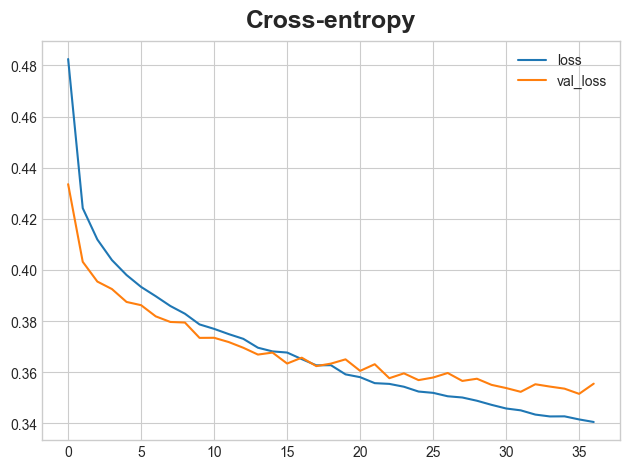

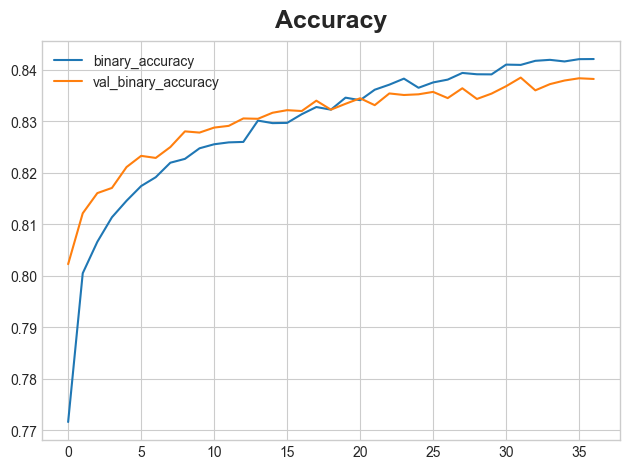

In [7]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=200,
    callbacks=[early_stopping],
)
# Evaluating Model Performance

#We visualize: training loss- validation loss- training accuracy- validation accuracy
#These learning curves help evaluate: convergence- model stability- overfitting behavior

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy")
history_df.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot(title="Accuracy")

# Model Evaluation

We evaluate the model using:
- classification metrics
- confusion matrix
- prediction analysis

This helps us understand how well the model distinguishes canceled and non-canceled bookings.

933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

           0       0.84      0.92      0.88     18792
           1       0.83      0.71      0.76     11056

    accuracy                           0.84     29848
   macro avg       0.84      0.81      0.82     29848
weighted avg       0.84      0.84      0.84     29848



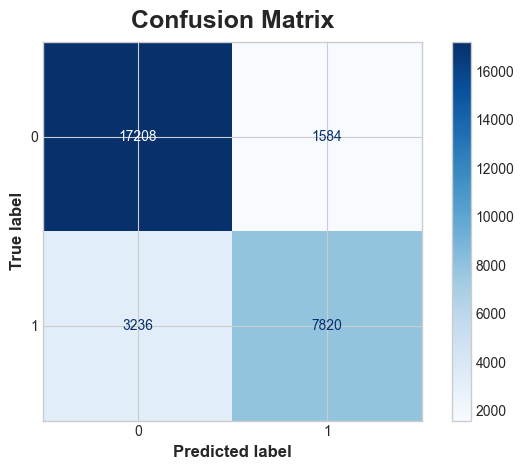

In [8]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Predict probabilities
y_pred_prob = model.predict(X_valid)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_valid, y_pred))
cm = confusion_matrix(y_valid, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()